## Titanic data 

#### importing libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')

loading the csv file directly onto a pandas dataframe. Using the shape method to view the dimensions and the df.head(*N*) function to show the first *N* rows of dataframe.

In [61]:
df = pd.read_csv('train.csv')
print('dataframe shape:', df.shape)
df.head(20)

dataframe shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


I will initialize a new dataframe based on the columns of the training data and the definitions that kaggle provided.

In [37]:
data = [
    {'Variable': 'surivial', 'Definition': '0 = No, 1 = Yes'},
    {'Variable': 'pclass', 'Definition': 'Ticket class 1 = 1st, 2 = 2nd, 3 = 3rd'},
    {'Variable': 'name', 'Definition': 'Passengers full name'},
    {'Variable': 'sex', 'Definition': 'male/female'},
    {'Variable': 'Age', 'Definition': 'Age in years'},
    {'Variable': 'sibsp', 'Definition': '# of siblings/spouses aboard the Titanic'},
    {'Variable': 'parch', 'Definition': '# of parents/children aboard the Titanic'},
    {'Variable': 'ticket', 'Definition': 'Ticket number'},
    {'Variable': 'fare', 'Definition': 'Passenger fare as a float'},
    {'Variable': 'cabin', 'Definition': 'Cabin number'},
    {'Variable': 'embarked', 'Definition': 'Port of embarkation C = Cherbourg, Q = Queenstown, S = Southampton'}                 
]

columns_dict = pd.DataFrame(data)
print(columns_dict)

    Variable                                         Definition
0   surivial                                    0 = No, 1 = Yes
1     pclass             Ticket class 1 = 1st, 2 = 2nd, 3 = 3rd
2       name                               Passengers full name
3        sex                                        male/female
4        Age                                       Age in years
5      sibsp           # of siblings/spouses aboard the Titanic
6      parch           # of parents/children aboard the Titanic
7     ticket                                      Ticket number
8       fare                          Passenger fare as a float
9      cabin                                       Cabin number
10  embarked  Port of embarkation C = Cherbourg, Q = Queenst...


### These are some functions that will provide an insight on the data

In [38]:
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [39]:
df.describe() # only sums numerical columns 

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.describe(include='str') # use include='str' to see info on stringed values

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


#### Missing Values

In [ ]:
df.isnull() # shows if the value is NaN note: 'isnull' is pandas 'isna' is python native 

708

number of passenders with at least one missing value in the data

In [68]:
len(df) - len(df.dropna()) 

708

Below is a dataframe mapping the columns to the total number of missing values in it and the percentage of its values missing 

In [71]:
missing_df = pd.DataFrame({
    'Missing Count' : df.isna().sum(),
    'Missing %' : (df.isna().sum() / df.shape[0] * 100).round(2)
})

missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending = False)
missing_df


,Missing Count,Missing %
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Ticket,0,0.00
Fare,0,0.00


#### Matplotlib graphs with the data

okay so i will make my first graph with the missing values

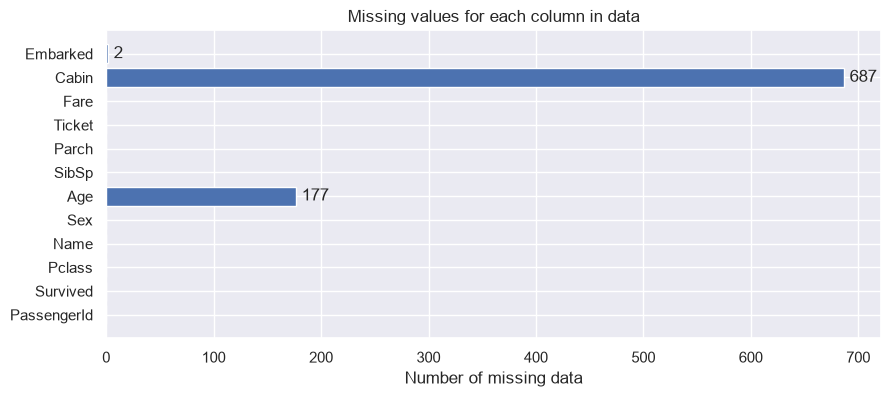

In [91]:
fig, ax = plt.subplots(figsize=(10,4))

columns = missing_df.index
missing_count = missing_df['Missing Count']

ax.barh(columns, missing_count)
ax.set_xlabel('Number of missing data')
ax.set_title('Missing values for each column in data')

for i, x in enumerate(missing_count):
    if x > 0:
        ax.text(x + 5, i, x, va = 'center')
plt.show()


next I will be showing a pie chart of the distribution of survived vs non survivors. Pretty neat huh!

Text(0.5, 1.0, 'Titanic survival rate')

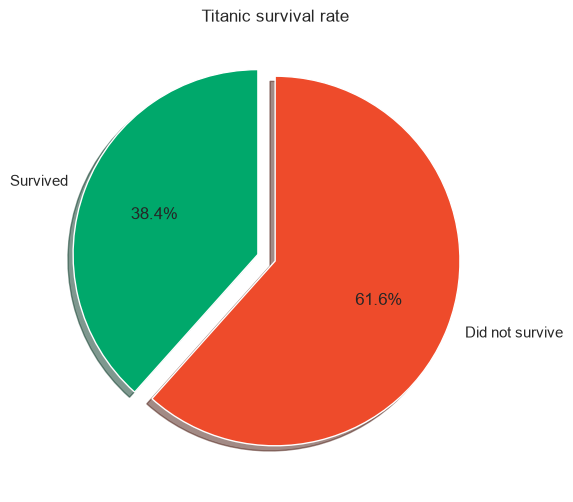

In [126]:
non_survivors = df[df['Survived'] == 0].shape[0]
survivors = df[df['Survived'] == 1].shape[0]
values=[survivors, non_survivors]
labels = ['Survived', 'Did not survive']
explosion = [0.1, 0]
colours = ['#00A86B', '#EE4B2B']

plt.figure(figsize=(6,6))
plt.pie(
    values,
    labels = labels,
    explode = explosion,
    autopct = '%1.1f%%',
    colors = colours,
    shadow = True,
    startangle = 90
)
plt.title('Titanic survival rate')

Alr next lets do some more data analysis on the other columns of the dataframe